# ANALYSE ET EXPLORATIONS DE DONNEES

In [1]:
# USHINDI MURHABAZI CHRISTOPHE
# Bac2 génie minier / EMI / UOB

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np  # calcul et algebre lineaire
import pandas as pd # gestion de la base de donnees
import matplotlib.pyplot as plt # gestion des graphes  - visualisation
import seaborn as sns # toujours pour la visualisation

## Chargement de donnees

In [5]:
donnees = pd.read_csv('/content/drive/MyDrive/Coffe_sales.csv', sep=',')
 #changer avec la direction de mon téléphone dans Google drive car j'utilise Google colab dans le téléphone

In [6]:
donnees.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [7]:
# Nombre de Lignes(data points) et des colonnes (Features- variables )
print('taille de la de donnees: ',donnees.shape)
print('Nombres de lignes:', donnees.shape[0])
print('Nombres de Colonnes:', donnees.shape[1])

taille de la de donnees:  (3547, 11)
Nombres de lignes: 3547
Nombres de Colonnes: 11


In [8]:
# informations sur les types de donnees dans nos colonnes

donnees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [9]:
# Verification de Valeurs manquante
donnees.isna().any()

,0
hour_of_day,False
cash_type,False
money,False
coffee_name,False
Time_of_Day,False
Weekday,False
Month_name,False
Weekdaysort,False
Monthsort,False
Date,False


In [10]:
# Description des valeurs numeriques:

donnees.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [11]:
donnees.describe().style.highlight_max(color='lightgreen',axis=0) # les statistique de vos donnees numerique

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [12]:
donnees.describe()[['money']]

,money
count,3547.000000
mean,31.645216
std,4.877754
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,38.700000


In [13]:
## types de nos variables

donnees.dtypes

,0
hour_of_day,int64
cash_type,object
money,float64
coffee_name,object
Time_of_Day,object
Weekday,object
Month_name,object
Weekdaysort,int64
Monthsort,int64
Date,object


In [14]:
# Netoyage de donnees :
# 1. Nettoyage de la colonne 'hour_of_day' si nécessaire
donnees['hour_of_day'] = donnees['hour_of_day'].astype(str).str.replace(',', '')
donnees['hour_of_day'] = donnees['hour_of_day'].astype(int)

# 2. Correction pour Month_name
dictionnaire_mois = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}


donnees['Month_name_numeric'] = donnees['Month_name'].map(dictionnaire_mois).astype(float)

In [15]:
donnees['hour_of_day'].dtype

dtype('int64')

In [16]:
# Puisque 'hour_of_day' est déjà un entier (int64),
# on peut directement passer à la suite ou simplement afficher les premières lignes pour vérifier :
donnees['hour_of_day'].head()

,hour_of_day
0,10
1,12
2,12
3,13
4,13


In [17]:
# Analyser la distribution des prix payés
print(donnees['money'].describe())
# Compter le nombre de ventes pour chaque type de café
print(donnees['coffee_name'].value_counts())

count    3547.000000
mean       31.645216
std         4.877754
min        18.120000
25%        27.920000
50%        32.820000
75%        35.760000
max        38.700000
Name: money, dtype: float64
coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64


In [18]:
donnees['money'].head()
donnees['coffee_name'].head()

,coffee_name
0,Latte
1,Hot Chocolate
2,Hot Chocolate
3,Americano
4,Latte


# Visualisation

/tmp/ipykernel_1093/288767161.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=donnees, x='coffee_name', order=donnees['coffee_name'].value_counts().index, palette='viridis')


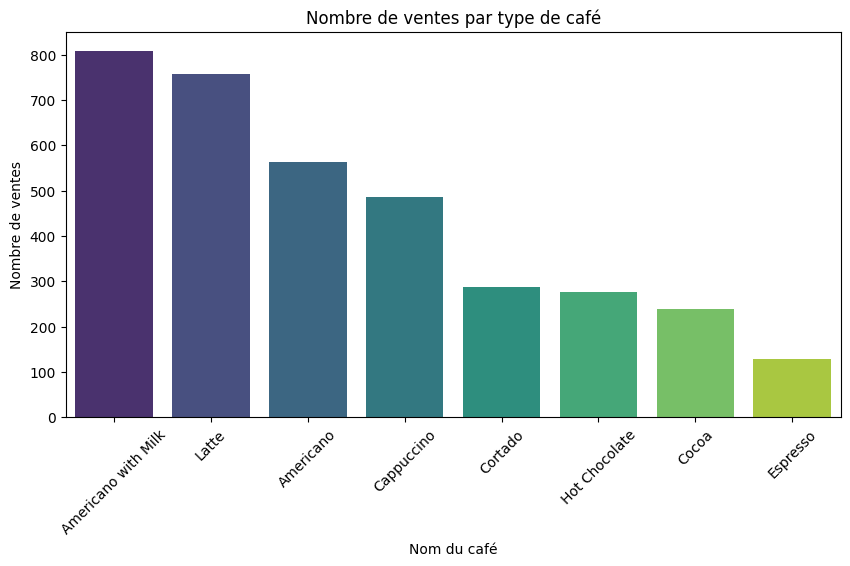

In [19]:

plt.figure(figsize=(10, 5))
# On crée un graphique en barres avec le décompte des cafés
sns.countplot(data=donnees, x='coffee_name', order=donnees['coffee_name'].value_counts().index, palette='viridis')
plt.title('Nombre de ventes par type de café')
plt.xlabel('Nom du café')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45)  # Incline les noms pour qu'ils soient lisibles
plt.show()

In [20]:
# Pour les colonnes non-essentielles (n'échoue pas si la colonne n'existe pas)
donnees.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')

In [21]:
donnees

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,Month_name_numeric
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000,3.0
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000,3.0
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000,3.0
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000,3.0
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000,3.0
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000,3.0
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000,3.0
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000,3.0


In [22]:
## Sauvegarde de donnees pour une manupilation Ulterieure
donnees.to_csv('donnees_emiexo1.csv', index= False)

In [23]:
# Compte des valeurs dans la colonne des modes de paiement
donnees['cash_type'].value_counts()

,count
cash_type,
card,3547


<Axes: ylabel='count'>

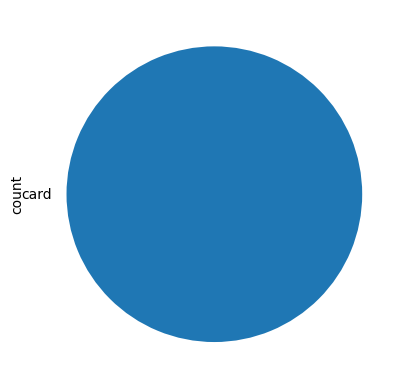

In [24]:
donnees['cash_type'].value_counts().plot(kind='pie')

<Axes: xlabel='cash_type'>

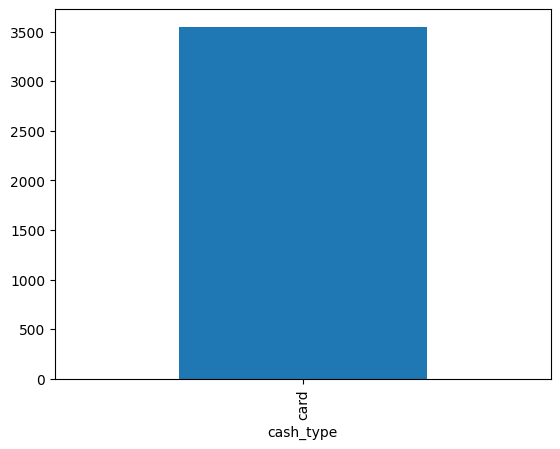

In [25]:
donnees['cash_type'].value_counts().plot(kind='bar')

In [26]:
# Les top 10 des transactions les plus chères (les plus grands montants de 'money')
classement_top10 = donnees.sort_values(by=['money'], ascending=False).head(10)
classement_top10

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,Month_name_numeric
131,10,card,38.7,Latte,Morning,Sat,Mar,6,3,2024-03-23,10:43:59.559000,3.0
133,13,card,38.7,Cappuccino,Afternoon,Sat,Mar,6,3,2024-03-23,13:10:07.661000,3.0
134,13,card,38.7,Cocoa,Afternoon,Sat,Mar,6,3,2024-03-23,13:11:12.230000,3.0
236,12,card,38.7,Cappuccino,Afternoon,Sun,Apr,7,4,2024-04-14,12:24:39.028000,4.0
235,17,card,38.7,Cappuccino,Night,Sat,Apr,6,4,2024-04-13,17:53:19.237000,4.0
234,17,card,38.7,Cappuccino,Night,Sat,Apr,6,4,2024-04-13,17:51:26.026000,4.0
233,16,card,38.7,Latte,Afternoon,Sat,Apr,6,4,2024-04-13,16:19:39.799000,4.0
232,16,card,38.7,Cappuccino,Afternoon,Sat,Apr,6,4,2024-04-13,16:18:03.938000,4.0
259,17,card,38.7,Cappuccino,Night,Wed,Apr,3,4,2024-04-17,17:02:40.687000,4.0
147,10,card,38.7,Latte,Morning,Tue,Mar,2,3,2024-03-26,10:42:30.170000,3.0


In [27]:
classement_top10.to_csv('top10_ventes_cafe.csv', index=False)

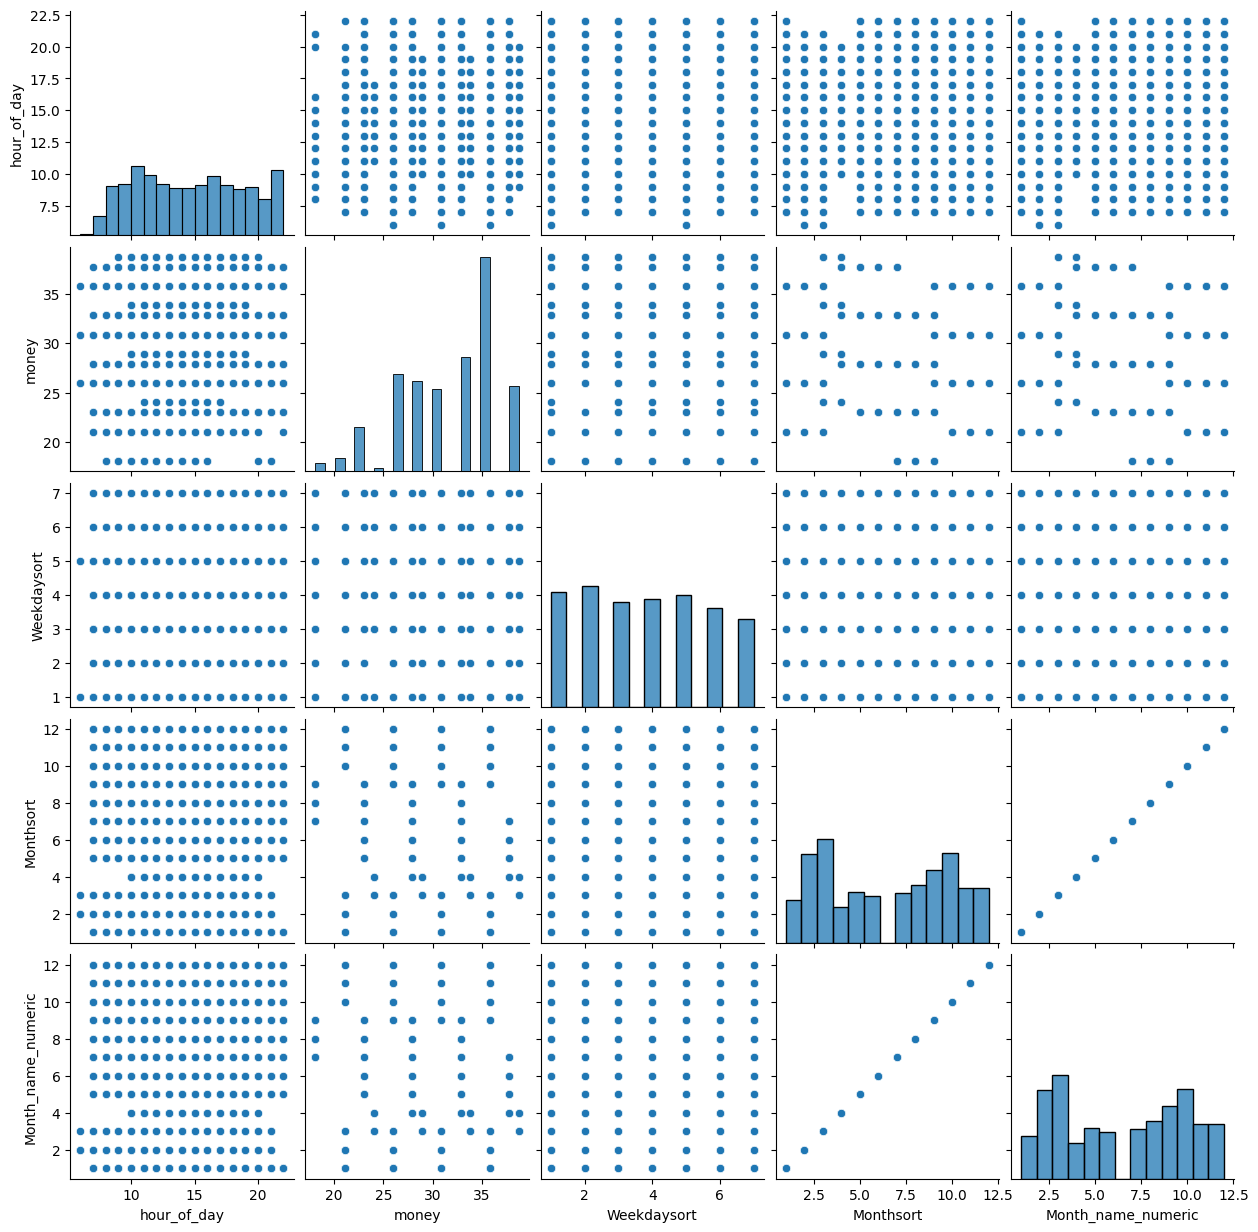

In [28]:
## Visualisation de relationes entres toutes les donnees et les distributions

sns.pairplot(donnees)
plt.show()

In [ ]:
donnees_numeriques = donnees.select_dtypes(include=['number'])

In [ ]:
donnees_numeriques

,hour_of_day,money,Weekdaysort,Monthsort,Month_name_numeric
0,10,38.70,5,3,3.0
1,12,38.70,5,3,3.0
2,12,38.70,5,3,3.0
3,13,28.90,5,3,3.0
4,13,38.70,5,3,3.0
...,...,...,...,...,...
3542,10,35.76,7,3,3.0
3543,14,35.76,7,3,3.0
3544,14,35.76,7,3,3.0
3545,15,25.96,7,3,3.0


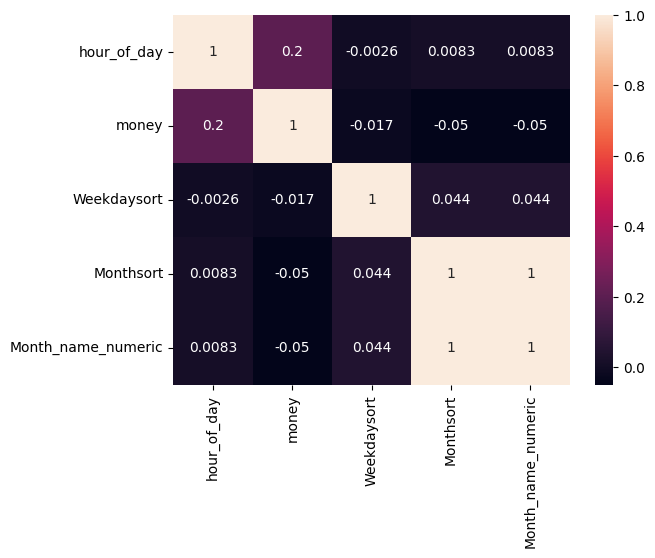

In [ ]:
# Correlation entre valeur numerique

sns.heatmap(donnees_numeriques.corr(),  annot = True)
plt.show()

In [ ]:
donnees_numeriques.corr()

,hour_of_day,money,Weekdaysort,Monthsort,Month_name_numeric
hour_of_day,1.000000,0.202748,-0.002614,0.008293,0.008293
money,0.202748,1.000000,-0.017264,-0.050043,-0.050043
Weekdaysort,-0.002614,-0.017264,1.000000,0.044141,0.044141
Monthsort,0.008293,-0.050043,0.044141,1.000000,1.000000
Month_name_numeric,0.008293,-0.050043,0.044141,1.000000,1.000000
